# Extreme sentiment analysis

The previous analyses suggested that sentiment variables exhibit limited predictive power for traditional forecasting tasks. However, sentiment may still contain useful information regarding periods of heightened market activity.

This section therefore investigates whether extreme sentiment events are associated with unusually large subsequent market movements. Rather than focusing on return direction, the analysis examines whether extreme sentiment is followed by increased return magnitude, elevated volatility, or abnormal stock performance relative to the broader market.

Three complementary analyses are conducted:

* **Extreme sentiment group comparison**: observations are classified into extreme positive, extreme negative, and neutral sentiment groups. Subsequent absolute returns and realized volatility are compared using the Mann–Whitney U test and Rank-Biserial Correlation effect sizes.

* **Probability of extreme future price movements**: the likelihood of observing a top-decile future absolute return is compared across sentiment groups using contingency tables and the chi-square test.

* **Abnormal return event study**: extreme sentiment days are treated as events and cumulative abnormal returns are tracked over a [-5, +5] trading-day window. Abnormal returns are calculated relative to the NASDAQ Composite Index in order to isolate stock-specific effects from broader market movements.


## 1. Configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from scipy.stats import mannwhitneyu
from scipy.stats import chi2_contingency
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="ticks", font_scale=1.1)

df = pd.read_csv('datasets/final/initial_processed_dataset.csv')
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

In [2]:
df['return_1d'] = (
    df.groupby('company')['close']
    .transform(lambda x: np.log(x / x.shift(1)))
)

The analysis focuses on future market outcomes rather than contemporaneous relationships.

A future 5-day return is constructed by aligning each observation with the return realized over the subsequent five trading days. The absolute value of this return is used to measure the magnitude of future price movements independently of direction.

Future realized volatility is represented by the 5-day log realized volatility target
(`target_log_volatility_5d`), which is already forward-looking by construction
(it summarizes returns over the following five trading days and is log-transformed
to reduce right-skewness). Missing sentiment values are replaced with zero,
indicating the absence of measurable sentiment activity on a given day.

In [3]:
df_analysis = df.copy()
 

df_analysis['return_5d_fwd'] = (
    df_analysis.groupby('company')['return_1d']
    .transform(lambda x: x.shift(-1).rolling(5).sum())
)
 
df_analysis['abs_return_5d_fwd'] = df_analysis['return_5d_fwd'].abs()

df_analysis['fwd_volatility'] = df_analysis['target_log_volatility_5d']
 
# Handle NaN values
df_analysis[['news_sentiment', 'reddit_sentiment']] = df_analysis[['news_sentiment', 'reddit_sentiment']].fillna(0)
 
df_analysis = df_analysis.dropna(
    subset=['abs_return_5d_fwd', 'fwd_volatility']
)
print(f'Shape after cleaning: {df_analysis.shape}')

Shape after cleaning: (7398, 61)


## 2. Extreme sentiment group comparison

Days are classified into three groups based on the distribution of
daily sentiment scores:

- **Extreme positive** — top 10% of sentiment values
- **Extreme negative** — bottom 10% of sentiment values
- **Neutral** — remaining 80%

The subsequent 5-day absolute return and 5-day log realized volatility
are compared across groups. Statistical significance is assessed using
the Mann-Whitney U test, which does not assume normality and is
therefore well suited for financial data.
In addition to statistical significance, Rank-Biserial Correlation (RBC) is reported as a measure of effect size.

The interpretation follows common guidelines:

| Absolute RBC | Interpretation |
|--------------|---------------|
| < 0.10 | Negligible |
| 0.10 – 0.30 | Small |
| 0.30 – 0.50 | Moderate |
| > 0.50 | Large |

While the Mann–Whitney U test indicates whether differences exist, RBC quantifies their practical magnitude.

In [4]:
def extreme_sentiment_analysis(df, sentiment_col, company=None, percentile=10):
    """
    Compares market outcomes across extreme and neutral sentiment groups.
 
    Parameters:
        df           : DataFrame with sentiment and market data
        sentiment_col: column name for sentiment scores
        company      : filter by company (None = all companies)
        percentile   : threshold for extreme sentiment (default 10%)
    """
 
    if company:
        data = df[df['company'] == company].copy()
    else:
        data = df.copy()
 
    low_threshold  = data[sentiment_col].quantile(percentile / 100)
    high_threshold = data[sentiment_col].quantile(1 - percentile / 100)
 
    data['sentiment_group'] = 'Neutral'
    data.loc[data[sentiment_col] >= high_threshold, 'sentiment_group'] = 'Extreme Positive'
    data.loc[data[sentiment_col] <= low_threshold,  'sentiment_group'] = 'Extreme Negative'
 
    results = []
 

    for metric, label in [
        ('abs_return_5d_fwd', '5-day |Return| (%)'),
        ('fwd_volatility',    '5-day Log Realized Volatility')
    ]:
 
        groups = {
            g: data[data['sentiment_group'] == g][metric].dropna()
            for g in ['Extreme Positive', 'Neutral', 'Extreme Negative']
        }
 
        # Mann-Whitney U test
        u_pos, p_pos = mannwhitneyu(
            groups['Extreme Positive'],
            groups['Neutral'],
            alternative='two-sided'
        )
 
        u_neg, p_neg = mannwhitneyu(
            groups['Extreme Negative'],
            groups['Neutral'],
            alternative='two-sided'
        )
 
        # Rank-Biserial Correlation
        n_pos = len(groups['Extreme Positive'])
        n_neg = len(groups['Extreme Negative'])
        n_neu = len(groups['Neutral'])
 
        rbc_pos = (2 * u_pos) / (n_pos * n_neu) - 1
        rbc_neg = (2 * u_neg) / (n_neg * n_neu) - 1
 
        for g, vals in groups.items():
            results.append({
                'metric': label,
                'group': g,
                'mean': vals.mean(),
                'median': vals.median(),
                'n': len(vals),
 
                'p_vs_neutral':
                    p_pos if g == 'Extreme Positive'
                    else (p_neg if g == 'Extreme Negative' else np.nan),
 
                'rbc_vs_neutral':
                    rbc_pos if g == 'Extreme Positive'
                    else (rbc_neg if g == 'Extreme Negative' else np.nan),
 
                'abs_rbc':
                    abs(rbc_pos) if g == 'Extreme Positive'
                    else (abs(rbc_neg) if g == 'Extreme Negative' else np.nan)
            })
 
    return pd.DataFrame(results), data

In [5]:
results_news_all, data_news = extreme_sentiment_analysis(
    df_analysis, 'news_sentiment'
)
results_reddit_all, data_reddit = extreme_sentiment_analysis(
    df_analysis, 'reddit_sentiment'
)

print('=== News sentiment — all companies ===')
print(results_news_all.to_string(index=False))
print('\n=== Reddit sentiment — all companies ===')
print(results_reddit_all.to_string(index=False))

=== News sentiment — all companies ===
                       metric            group     mean   median    n  p_vs_neutral  rbc_vs_neutral  abs_rbc
           5-day |Return| (%) Extreme Positive 0.059783 0.046109  740  2.090836e-11        0.150829 0.150829
           5-day |Return| (%)          Neutral 0.047396 0.035604 5918           NaN             NaN      NaN
           5-day |Return| (%) Extreme Negative 0.056043 0.042738  740  8.776355e-06        0.100079 0.100079
5-day Log Realized Volatility Extreme Positive 3.638421 3.639982  740  1.010490e-05        0.099395 0.099395
5-day Log Realized Volatility          Neutral 3.516861 3.545790 5918           NaN             NaN      NaN
5-day Log Realized Volatility Extreme Negative 3.675734 3.670874  740  2.407407e-09        0.134351 0.134351

=== Reddit sentiment — all companies ===
                       metric            group     mean   median    n  p_vs_neutral  rbc_vs_neutral  abs_rbc
           5-day |Return| (%) Extreme Positive 

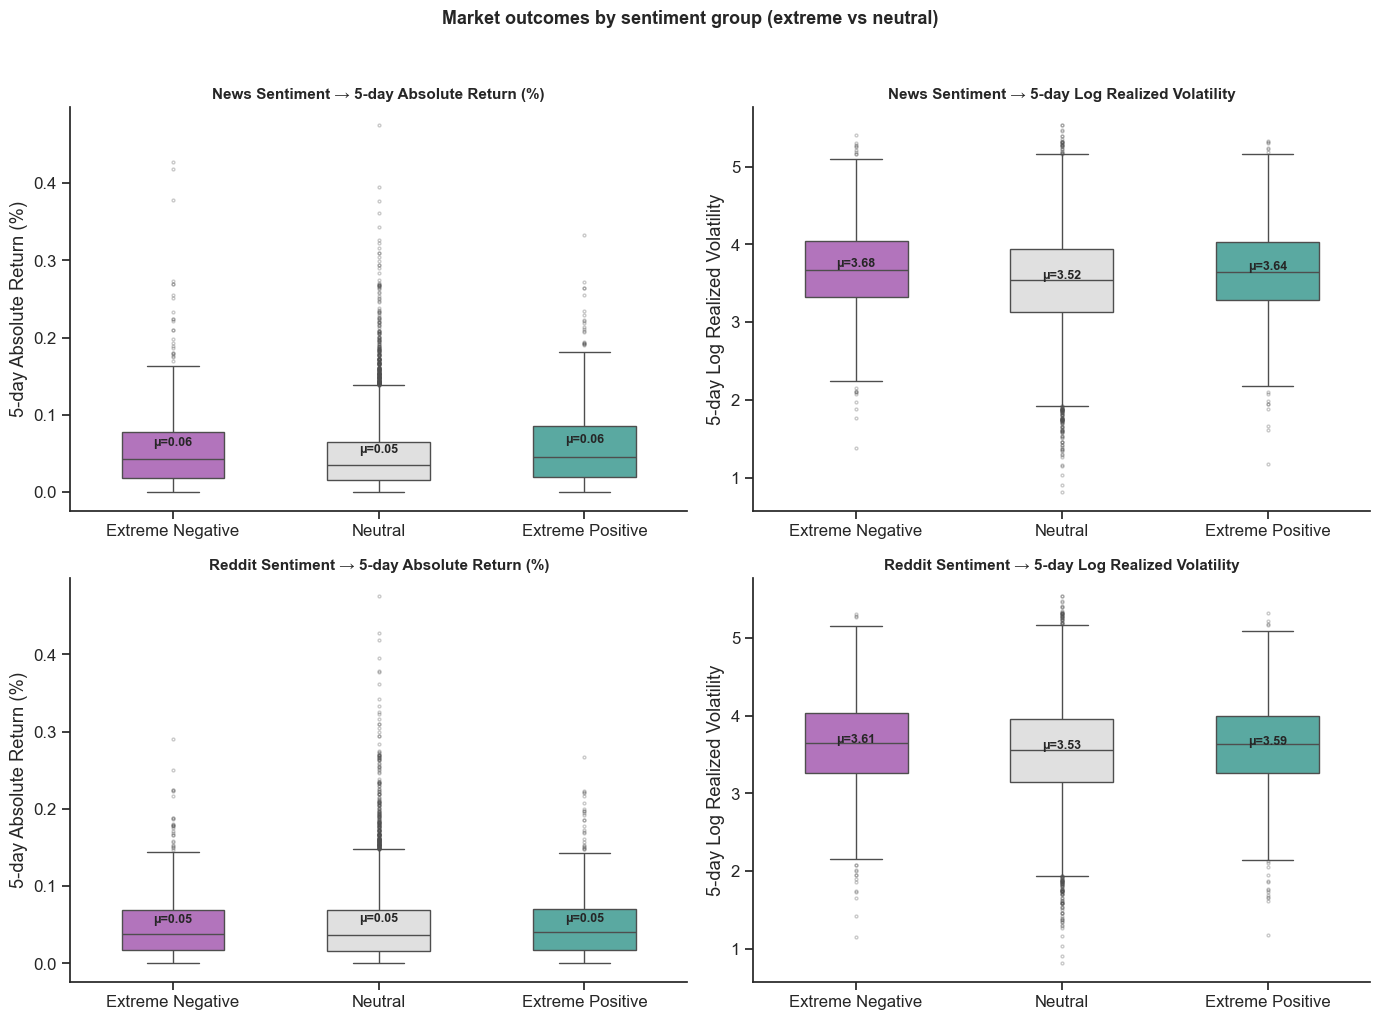

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
 
group_order  = ['Extreme Negative', 'Neutral', 'Extreme Positive']
group_colors = ['#BA68C8', '#E0E0E0', '#4DB6AC']
 
for row, (sentiment_col, label, data) in enumerate([
    ('news_sentiment',   'News Sentiment',   data_news),
    ('reddit_sentiment', 'Reddit Sentiment', data_reddit)
]):
    for col, (metric, metric_label) in enumerate([
        ('abs_return_5d_fwd', '5-day Absolute Return (%)'),
        ('fwd_volatility',    '5-day Log Realized Volatility')
    ]):
        ax = axes[row, col]
 
        sns.boxplot(
            data=data,
            x='sentiment_group',
            y=metric,
            order=group_order,
            palette=group_colors,
            ax=ax,
            width=0.5,
            flierprops=dict(marker='o', markersize=2, alpha=0.3)
        )
 
        # Add mean value
        means = data.groupby('sentiment_group')[metric].mean()
        for i, g in enumerate(group_order):
            if g in means:
                ax.text(i, means[g], f'μ={means[g]:.2f}',
                        ha='center', va='bottom', fontsize=9,
                        fontweight='bold')
 
        ax.set_title(f'{label} → {metric_label}',
                     fontsize=11, fontweight='bold')
        ax.set_xlabel('')
        ax.set_ylabel(metric_label)
        sns.despine(ax=ax)
 
plt.suptitle('Market outcomes by sentiment group (extreme vs neutral)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [7]:
print('=== Results by company — News sentiment ===\n')

summary_rows = []

for company in ['NVDA', 'AMD', 'INTC']:
    res, _ = extreme_sentiment_analysis(
        df_analysis, 'news_sentiment', company=company
    )
    res['company'] = company
    summary_rows.append(res)

summary_df = pd.concat(summary_rows, ignore_index=True)

for metric in summary_df['metric'].unique():
    print(f'\n{metric}:')
    pivot = (
        summary_df[summary_df['metric'] == metric]
        .pivot(index='company', columns='group', values='mean')
        [['Extreme Negative', 'Neutral', 'Extreme Positive']]
        .round(2)
    )
    print(pivot.to_string())

=== Results by company — News sentiment ===


5-day |Return| (%):
group    Extreme Negative  Neutral  Extreme Positive
company                                             
AMD                  0.06     0.06              0.07
INTC                 0.05     0.04              0.05
NVDA                 0.06     0.05              0.06

5-day Log Realized Volatility:
group    Extreme Negative  Neutral  Extreme Positive
company                                             
AMD                  3.79     3.75              3.80
INTC                 3.46     3.25              3.35
NVDA                 3.79     3.57              3.59


## 3. Probability of extreme future price movements

The previous analysis compared distributions of future market outcomes across sentiment groups. This section provides a more intuitive perspective by examining the likelihood of observing unusually large future price movements.

A large future move is defined as a future 5-day absolute return belonging to the top decile of all observations. The probability of such events is computed separately for extreme positive, extreme negative, and neutral sentiment days.

Statistical significance is assessed using the chi-square test of independence.

In [8]:
def large_move_probability_analysis(df, sentiment_col, percentile=10, move_quantile=0.90):
    data = df.copy()

    low_threshold = data[sentiment_col].quantile(percentile / 100)
    high_threshold = data[sentiment_col].quantile(1 - percentile / 100)

    data['sentiment_group'] = 'Neutral'
    data.loc[data[sentiment_col] >= high_threshold, 'sentiment_group'] = 'Extreme Positive'
    data.loc[data[sentiment_col] <= low_threshold, 'sentiment_group'] = 'Extreme Negative'

    move_threshold = data['abs_return_5d_fwd'].quantile(move_quantile)

    data['large_move'] = (
        data['abs_return_5d_fwd'] >= move_threshold
    ).astype(int)

    prob_table = (
        data.groupby('sentiment_group', observed=True)['large_move']
        .agg(
            n='count',
            large_moves='sum',
            probability='mean'
        )
        .reset_index()
    )

    prob_table['probability_pct'] = prob_table['probability'] * 100

    neutral_prob = prob_table.loc[
        prob_table['sentiment_group'] == 'Neutral',
        'probability'
    ].iloc[0]

    prob_table['relative_risk_vs_neutral'] = (
        prob_table['probability'] / neutral_prob
    )

    contingency = pd.crosstab(
        data['sentiment_group'],
        data['large_move']
    )

    chi2, p_value, dof, expected = chi2_contingency(contingency)

    stats = {
        'move_threshold': move_threshold,
        'chi2': chi2,
        'p_value': p_value,
        'dof': dof
    }

    group_order = ['Extreme Negative', 'Neutral', 'Extreme Positive']

    prob_table['sentiment_group'] = pd.Categorical(
        prob_table['sentiment_group'],
        categories=group_order,
        ordered=True
    )

    prob_table = prob_table.sort_values('sentiment_group')

    return prob_table, contingency, stats, data

In [9]:
prob_news, cont_news, stats_news, data_news_prob = large_move_probability_analysis(
    df_analysis,
    'news_sentiment'
)

prob_reddit, cont_reddit, stats_reddit, data_reddit_prob = large_move_probability_analysis(
    df_analysis,
    'reddit_sentiment'
)

print('=== News sentiment — probability of large future moves ===')
print(prob_news.to_string(index=False))
print('\nChi-square stats:')
print(stats_news)

print('\n=== Reddit sentiment — probability of large future moves ===')
print(prob_reddit.to_string(index=False))
print('\nChi-square stats:')
print(stats_reddit)

=== News sentiment — probability of large future moves ===
 sentiment_group    n  large_moves  probability  probability_pct  relative_risk_vs_neutral
Extreme Negative  740          101     0.136486        13.648649                  1.526894
         Neutral 5918          529     0.089388         8.938831                  1.000000
Extreme Positive  740          110     0.148649        14.864865                  1.662954

Chi-square stats:
{'move_threshold': np.float64(0.10825112677469842), 'chi2': np.float64(37.80086554937963), 'p_value': np.float64(6.189368500931686e-09), 'dof': 2}

=== Reddit sentiment — probability of large future moves ===
 sentiment_group    n  large_moves  probability  probability_pct  relative_risk_vs_neutral
Extreme Negative  740           67     0.090541         9.054054                  0.888589
         Neutral 5918          603     0.101893        10.189253                  1.000000
Extreme Positive  740           70     0.094595         9.459459            

In [10]:
group_order = ['Extreme Negative', 'Neutral', 'Extreme Positive']

prob_news['sentiment_group'] = pd.Categorical(
    prob_news['sentiment_group'],
    categories=group_order,
    ordered=True
)

prob_reddit['sentiment_group'] = pd.Categorical(
    prob_reddit['sentiment_group'],
    categories=group_order,
    ordered=True
)

prob_news = prob_news.sort_values('sentiment_group')
prob_reddit = prob_reddit.sort_values('sentiment_group')

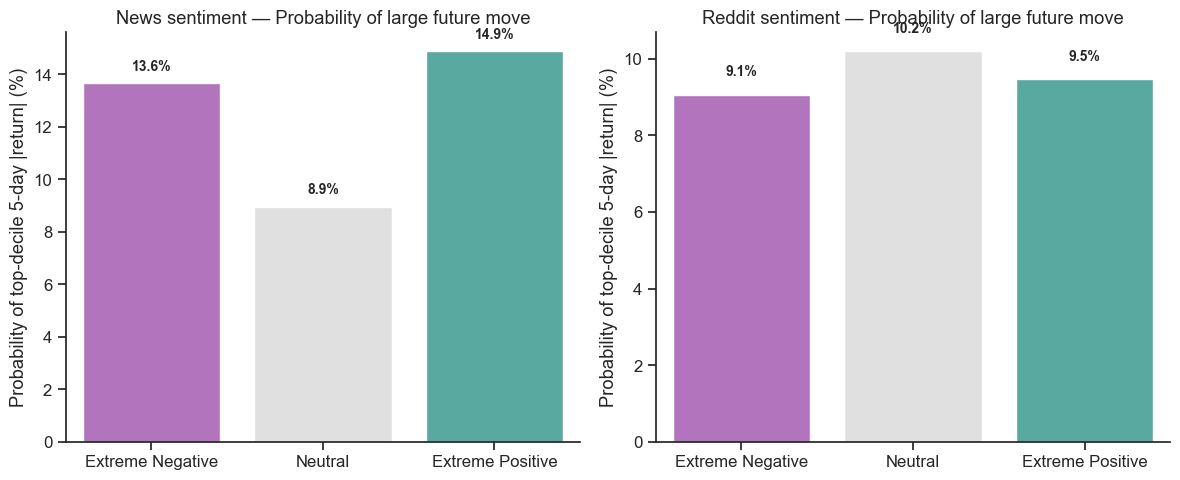

In [11]:
group_order = ['Extreme Negative', 'Neutral', 'Extreme Positive']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, prob_table, title in [
    (axes[0], prob_news, 'News sentiment'),
    (axes[1], prob_reddit, 'Reddit sentiment')
]:
    sns.barplot(
        data=prob_table,
        x='sentiment_group',
        y='probability_pct',
        order=group_order,
        palette=['#BA68C8', '#E0E0E0', '#4DB6AC'],
        ax=ax
    )

    for i, row in enumerate(prob_table.itertuples()):
        ax.text(
            i,
            row.probability_pct + 0.5,
            f'{row.probability_pct:.1f}%',
            ha='center',
            fontsize=10,
            fontweight='bold'
        )

    ax.set_title(f'{title} — Probability of large future move')
    ax.set_xlabel('')
    ax.set_ylabel('Probability of top-decile 5-day |return| (%)')
    sns.despine(ax=ax)

plt.tight_layout()
plt.show()

## 4. Abnormal return event study

The previous analyses suggested that extreme sentiment is associated with larger future price movements and higher volatility. However, raw stock returns may partly reflect broader market conditions rather than stock-specific reactions.

To address this issue, an abnormal return event study is conducted. Daily abnormal returns are computed as the difference between the stock return and the corresponding NASDAQ Composite return:

$$
AR_t = R_{i,t} - R_{m,t}
$$

where:

* $AR_t$ is the abnormal return at time $t$,
* $R_{i,t}$ is the return of stock $i$ at time $t$,
* $R_{m,t}$ is the market return (NASDAQ Composite) at time $t$.

Cumulative abnormal returns are then computed as:

$$
CAR_{(t_1,t_2)} = \sum_{t=t_1}^{t_2} AR_t
$$

where $CAR_{(t_1,t_2)}$ represents the cumulative abnormal return over the event window.

Extreme sentiment days are treated as events, and cumulative abnormal returns (CAR) are tracked over a symmetric [-5, +5] trading-day window. This allows the examination of stock performance before and after extreme sentiment events while controlling for general market movements.

By removing broad market effects, the abnormal return framework helps isolate stock-specific performance associated with extreme sentiment events and allows the assessment of whether the observed relationships persist beyond overall market trends.


In [12]:
df_analysis = df.copy()

# Sentiment missing values are interpreted as no available sentiment signal.
df_analysis[['news_sentiment', 'reddit_sentiment']] = (
    df_analysis[['news_sentiment', 'reddit_sentiment']].fillna(0)
)

# Abnormal return:
# return_1d and nasdaq_return are both expressed in percentages.
df_analysis['abnormal_return'] = (
    df_analysis['return_1d'] - df_analysis['nasdaq_return']
)

# Drop rows required for event study
df_analysis = df_analysis.dropna(
    subset=[
        'company',
        'date',
        'return_1d',
        'nasdaq_return',
        'abnormal_return',
        'news_sentiment',
        'reddit_sentiment'
    ]
).reset_index(drop=True)

print(df_analysis.shape)
df_analysis[['date', 'company', 'return_1d', 'nasdaq_return', 'abnormal_return',
             'news_sentiment', 'reddit_sentiment']].head()

(7410, 59)


,date,company,return_1d,nasdaq_return,abnormal_return,news_sentiment,reddit_sentiment
0,2016-06-01,NVDA,0.001924,0.084886,-0.082962,-0.103654,0.048949
1,2016-06-01,INTC,0.002213,0.084886,-0.082672,-0.069816,0.000000
2,2016-06-01,AMD,-0.031114,0.084886,-0.116000,-0.209999,-0.020459
3,2016-06-02,NVDA,0.007025,0.385882,-0.378858,0.063405,0.092831
4,2016-06-02,INTC,0.003154,0.385882,-0.382729,0.188640,0.000000


In [13]:
def abnormal_return_event_study(
    df,
    sentiment_col,
    return_col='abnormal_return',
    window=5,
    percentile=10
):
    """
    Conducts an event study around extreme sentiment days using abnormal returns.
    
    Extreme positive events are defined as the top percentile of sentiment values.
    Extreme negative events are defined as the bottom percentile of sentiment values.
    
    The function returns average abnormal returns and cumulative abnormal returns
    over the [-window, +window] trading-day event window.
    """

    data = df.copy()

    low_threshold = data[sentiment_col].quantile(percentile / 100)
    high_threshold = data[sentiment_col].quantile(1 - percentile / 100)

    results = {
        'Extreme Positive': [],
        'Extreme Negative': []
    }

    for company in data['company'].unique():
        comp_df = (
            data[data['company'] == company]
            .sort_values('date')
            .reset_index(drop=True)
        )

        event_definitions = [
            (
                'Extreme Positive',
                comp_df[sentiment_col] >= high_threshold
            ),
            (
                'Extreme Negative',
                comp_df[sentiment_col] <= low_threshold
            )
        ]

        for event_type, condition in event_definitions:
            event_indices = comp_df[condition].index.tolist()

            for idx in event_indices:
                start = idx - window
                end = idx + window + 1

                if start < 0 or end > len(comp_df):
                    continue

                window_returns = comp_df.loc[start:end - 1, return_col].values

                if len(window_returns) == 2 * window + 1:
                    results[event_type].append(window_returns)

    days = list(range(-window, window + 1))
    cumulative = {}

    for event_type, all_windows in results.items():
        if len(all_windows) == 0:
            continue

        arr = np.array(all_windows)

        aar = arr.mean(axis=0)
        car = np.cumsum(aar)

        # Standard error of daily abnormal returns
        aar_se = arr.std(axis=0, ddof=1) / np.sqrt(len(all_windows))

        # Standard error of CAR:
        # compute cumulative abnormal return for each event window first
        car_by_event = np.cumsum(arr, axis=1)
        car_se = car_by_event.std(axis=0, ddof=1) / np.sqrt(len(all_windows))

        cumulative[event_type] = {
            'days': days,
            'aar': aar,
            'car': car,
            'aar_se': aar_se,
            'car_se': car_se,
            'n_events': len(all_windows),
            'event_windows': arr
        }

    return cumulative

In [14]:
es_news_ar = abnormal_return_event_study(
    df_analysis,
    sentiment_col='news_sentiment',
    return_col='abnormal_return',
    window=5,
    percentile=10
)

es_reddit_ar = abnormal_return_event_study(
    df_analysis,
    sentiment_col='reddit_sentiment',
    return_col='abnormal_return',
    window=5,
    percentile=10
)

for source_name, es in [
    ('News', es_news_ar),
    ('Reddit', es_reddit_ar)
]:
    for event_type, data in es.items():
        print(f'{source_name} — {event_type}: {data["n_events"]} events')

News — Extreme Positive: 741 events
News — Extreme Negative: 737 events
Reddit — Extreme Positive: 737 events
Reddit — Extreme Negative: 737 events


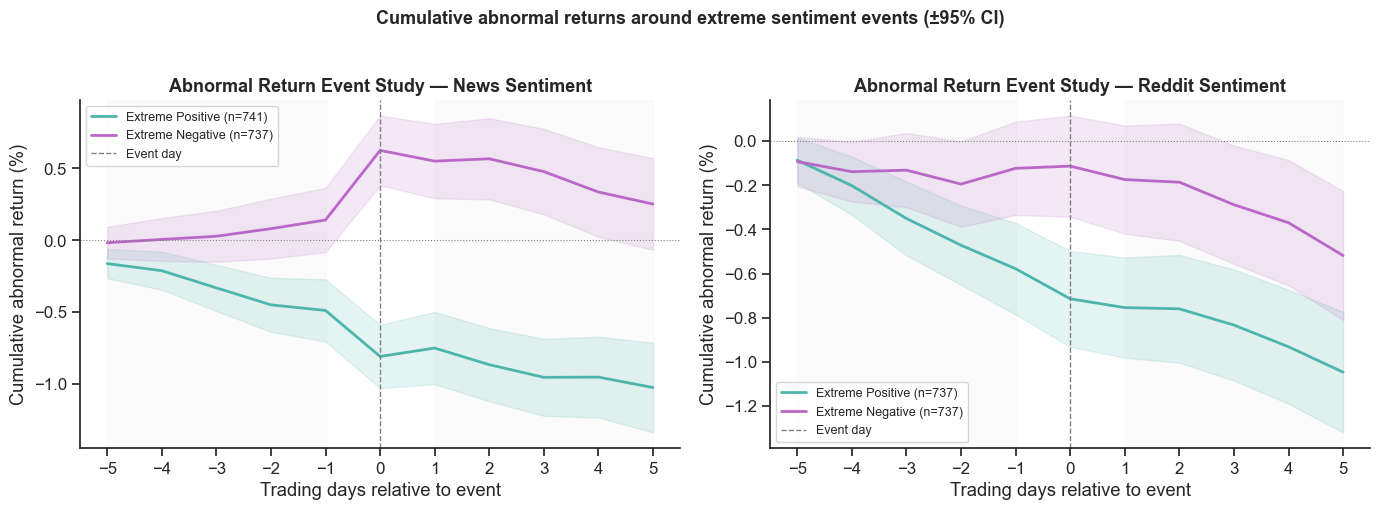

In [15]:
def plot_abnormal_event_study(es_news, es_reddit):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    colors = {
        'Extreme Positive': '#4DB6AC',
        'Extreme Negative': '#BA68C8'
    }

    for ax, es_data, title in [
        (axes[0], es_news, 'News Sentiment'),
        (axes[1], es_reddit, 'Reddit Sentiment')
    ]:
        for event_type, data in es_data.items():
            days = data['days']
            car = data['car']
            se = data['car_se']
            n = data['n_events']

            ax.plot(
                days,
                car,
                linewidth=2,
                color=colors[event_type],
                label=f'{event_type} (n={n})'
            )

            ax.fill_between(
                days,
                car - 1.96 * se,
                car + 1.96 * se,
                alpha=0.15,
                color=colors[event_type]
            )

        ax.axvline(0, color='gray', linewidth=1, linestyle='--', label='Event day')
        ax.axhline(0, color='gray', linewidth=0.8, linestyle=':')
        ax.axvspan(-5, -1, alpha=0.03, color='gray')
        ax.axvspan(1, 5, alpha=0.03, color='gray')

        ax.set_xlabel('Trading days relative to event')
        ax.set_ylabel('Cumulative abnormal return (%)')
        ax.set_title(f'Abnormal Return Event Study — {title}',
                     fontsize=13, fontweight='bold')
        ax.set_xticks(range(-5, 6))
        ax.legend(fontsize=9)
        sns.despine(ax=ax)

    plt.suptitle(
        'Cumulative abnormal returns around extreme sentiment events (±95% CI)',
        fontsize=13,
        fontweight='bold',
        y=1.02
    )

    plt.tight_layout()
    plt.show()


plot_abnormal_event_study(es_news_ar, es_reddit_ar)

In [16]:
def abnormal_event_study_stats(es_data, source_label):
    """
    Computes t-tests for cumulative abnormal returns at selected horizons.
    """

    rows = []

    for event_type, data in es_data.items():
        days = data['days']
        arr = data['event_windows']
        n = data['n_events']

        car_by_event = np.cumsum(arr, axis=1)

        for horizon in [1, 3, 5]:
            idx = days.index(horizon)

            car_values = car_by_event[:, idx]

            mean_car = car_values.mean()
            std_err = car_values.std(ddof=1) / np.sqrt(n)

            t_stat, p_value = stats.ttest_1samp(car_values, popmean=0)

            rows.append({
                'source': source_label,
                'event_type': event_type,
                'horizon': f'+{horizon}d',
                'mean_CAR_%': round(mean_car, 3),
                'std_err': round(std_err, 3),
                't_stat': round(t_stat, 3),
                'p_value': round(p_value, 4),
                'significant': p_value < 0.05,
                'n_events': n
            })

    return pd.DataFrame(rows)


stats_news_ar = abnormal_event_study_stats(es_news_ar, 'News')
stats_reddit_ar = abnormal_event_study_stats(es_reddit_ar, 'Reddit')

stats_combined_ar = pd.concat(
    [stats_news_ar, stats_reddit_ar],
    ignore_index=True
)

print('=== Abnormal Return Event Study — CAR at Key Horizons ===\n')
print(stats_combined_ar.to_string(index=False))

=== Abnormal Return Event Study — CAR at Key Horizons ===

source       event_type horizon  mean_CAR_%  std_err  t_stat  p_value  significant  n_events
  News Extreme Positive     +1d      -0.749    0.128  -5.837   0.0000         True       741
  News Extreme Positive     +3d      -0.953    0.137  -6.979   0.0000         True       741
  News Extreme Positive     +5d      -1.024    0.159  -6.431   0.0000         True       741
  News Extreme Negative     +1d       0.551    0.132   4.175   0.0000         True       737
  News Extreme Negative     +3d       0.478    0.152   3.149   0.0017         True       737
  News Extreme Negative     +5d       0.252    0.162   1.554   0.1206        False       737
Reddit Extreme Positive     +1d      -0.754    0.116  -6.508   0.0000         True       737
Reddit Extreme Positive     +3d      -0.833    0.128  -6.485   0.0000         True       737
Reddit Extreme Positive     +5d      -1.046    0.139  -7.519   0.0000         True       737
Reddit Extr

If cumulative abnormal returns remain statistically significant after removing general market movements, this suggests that extreme sentiment contains information beyond overall market trends.

Conversely, if abnormal return effects disappear, the previously observed relationships may primarily reflect broad market dynamics rather than sentiment-specific effects.